In [1]:
from datetime import datetime
import math
import numpy as np
from tbparse import SummaryReader
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style for the plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

2026-01-08 17:46:35.207546: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-08 17:46:36.451538: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-08 17:46:40.717788: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/boran/DRe-SCale/venv/lib/python3.12/site-packages/ker

In [5]:
# 1. Setup the reader (same as before)
log_dir = "./logs/evaluation/20260107-182325/PPO_LSTM_Run1"  # Keep your timestamp
reader = SummaryReader(log_dir, pivot=True)

# 2. DEBUG: Ask it what tags it found
print("Found Tags:", reader.get_tags())

# 3. TRY THIS: Read from 'tensors' instead of 'scalars'
df = reader.tensors 

print("\nData Found:")
print(df.head())

Found Tags: {'images': [], 'audio': [], 'histograms': [], 'scalars': [], 'tensors': ['avg_execution_time', 'throughput', 'requests', 'replicas', 'cpu', 'mem', 'episode', 'action', 'n-step_reward', 'episodic_reward', 'reward summary'], 'hparams': [], 'text': []}

Data Found:
   step  action  avg_execution_time     cpu  episode  \
0     0     2.0               0.495  0.0225      0.0   
1     1     1.0               1.565  0.0090      0.0   
2     2     1.0               0.438  0.0349      0.0   
3     3     1.0               0.007  0.0089      0.0   
4     4     2.0               0.009  0.0158      0.0   

                  episodic_reward     mem  n-step_reward  replicas  requests  \
0                    70030.820312  0.1447    3776.590088       6.0       7.0   
1     [70030.8203125, 74789.0625]  0.1443    7492.919922       7.0       1.0   
2       [74789.0625, 72692.03125]  0.1422    7489.959961       8.0      15.0   
3    [74456.0234375, 72692.03125]  0.1420    7485.890137       9.0  

In [6]:
import os

# Use the path you tried
target_dir = "./logs/evaluation/20260107-182325/PPO_LSTM_Run1"

print(f"Checking: {target_dir}")
if os.path.exists(target_dir):
    files = os.listdir(target_dir)
    print(f"Files found: {files}")
    for f in files:
        full_path = os.path.join(target_dir, f)
        size = os.path.getsize(full_path)
        print(f" - {f}: {size} bytes")
else:
    print("❌ Directory not found. Please check the timestamp folder name in 'logs/evaluation/'")

Checking: ./logs/evaluation/20260107-182325/PPO_LSTM_Run1
Files found: ['events.out.tfevents.1767799405.TardisV3.67559.0.v2']
 - events.out.tfevents.1767799405.TardisV3.67559.0.v2: 124519 bytes


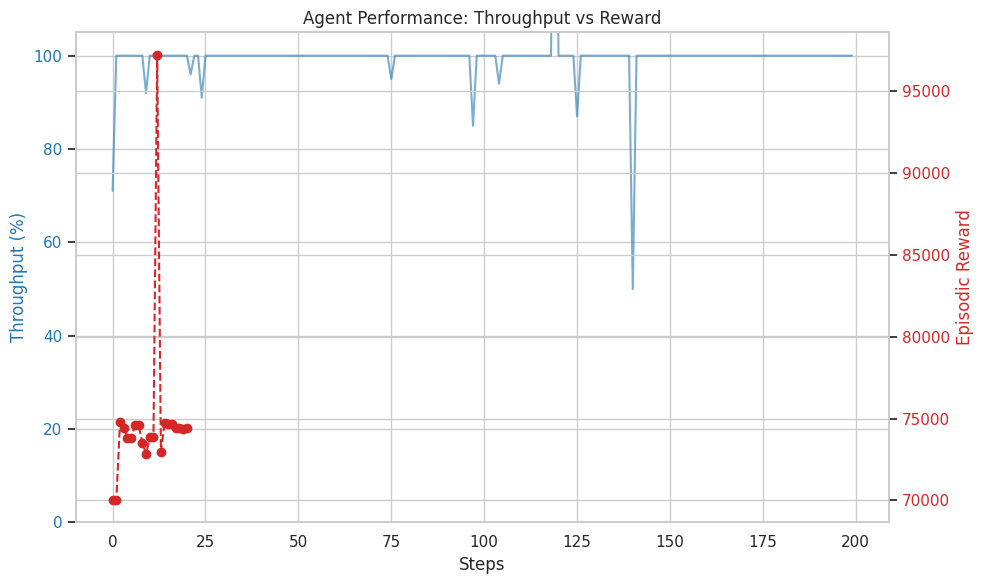

In [7]:
# 1. Load the data
df = reader.tensors
df = df.reset_index()  # Make 'step' a regular column

# --- HELPER FUNCTION TO FIX THE "LIST" ERROR ---
def clean_metric(series):
    """
    Extracts scalar values if they are wrapped in lists or arrays.
    Example: Converts [100.0] -> 100.0
    """
    def extract(x):
        # If it's a list or numpy array, grab the first item
        if isinstance(x, (list, np.ndarray)):
            return x[0] if len(x) > 0 else 0
        # If it's a numpy 0-d array (scalar), convert to float
        if hasattr(x, 'item'):
            return x.item()
        return x

    return series.apply(extract)
# -----------------------------------------------

# 2. Get Columns and Clean Them
steps = df['step']

if 'throughput' in df.columns:
    # Clean the throughput column!
    throughput = clean_metric(df['throughput'])
else:
    print("Warning: 'throughput' not found. Plotting zeros.")
    throughput = [0] * len(steps)

if 'episodic_reward' in df.columns:
    # Clean the reward column!
    reward = clean_metric(df['episodic_reward'])
else:
    print("Warning: 'episodic_reward' not found. Plotting zeros.")
    reward = [0] * len(steps)

# 3. Create the dual-axis plot
fig, ax1 = plt.subplots()

# Plot Throughput (Blue)
color = 'tab:blue'
ax1.set_xlabel('Steps')
ax1.set_ylabel('Throughput (%)', color=color)
ax1.plot(steps, throughput, color=color, alpha=0.6, label='Throughput')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 105)

# Plot Reward (Red) on the right axis
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Episodic Reward', color=color)
ax2.plot(steps, reward, color=color, marker='o', linestyle='--', label='Reward')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Agent Performance: Throughput vs Reward')
fig.tight_layout()
plt.show()

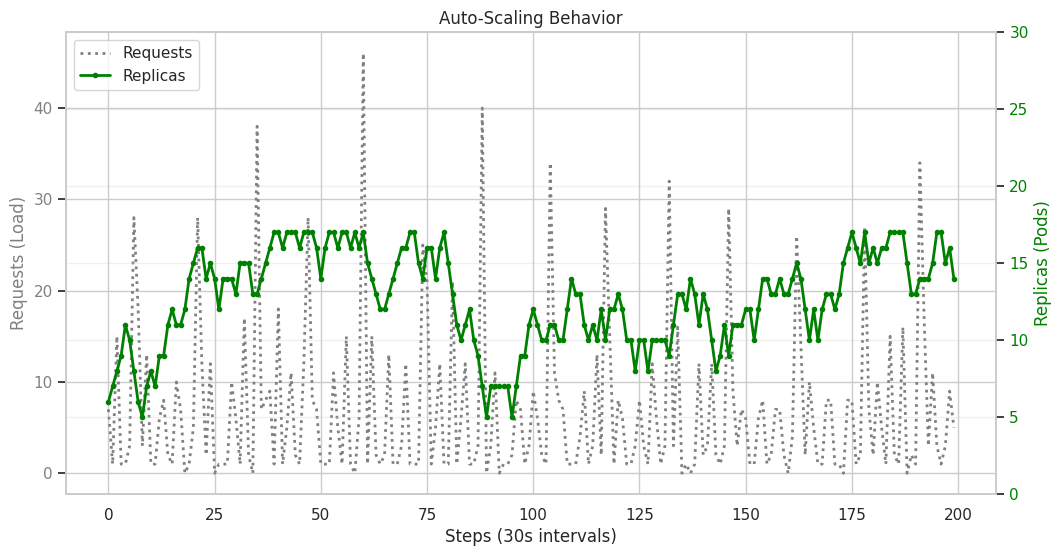

In [8]:
# Ensure we use the cleaned dataframe from the previous step
# (Assuming 'df' is loaded and 'clean_metric' is defined)

# 1. Prepare the Data
steps = df['step']

# Clean the Replicas and Requests columns
if 'replicas' in df.columns:
    replicas = clean_metric(df['replicas'])
else:
    print("Warning: 'replicas' column missing.")
    replicas = [0] * len(steps)

if 'requests' in df.columns:
    requests = clean_metric(df['requests'])
else:
    print("Warning: 'requests' column missing.")
    requests = [0] * len(steps)

# 2. Create the Plot
plt.figure(figsize=(12, 6))

# Plot Requests (The Load) on the Left Axis
ax1 = plt.gca() # Get current axis
ax1.set_xlabel('Steps (30s intervals)')
ax1.set_ylabel('Requests (Load)', color='grey')
# Use a dotted line for requests to make it distinct
line1 = ax1.plot(steps, requests, label='Requests', color='grey', linestyle=':', linewidth=2)
ax1.tick_params(axis='y', labelcolor='grey')

# Plot Replicas (The Agent's Response) on the Right Axis
ax2 = ax1.twinx()
ax2.set_ylabel('Replicas (Pods)', color='green')
# Use a solid green line for the agent's scaling decisions
line2 = ax2.plot(steps, replicas, label='Replicas', color='green', linewidth=2, marker='.')
ax2.tick_params(axis='y', labelcolor='green')

# Set limits for replicas (0 to Max Pods + small buffer)
# You defined MAX_PODS = 24 in your environment
ax2.set_ylim(0, 30)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Auto-Scaling Behavior')
plt.grid(True, alpha=0.3)
plt.show()

Reading logs from: logs/PPO_LSTM_Run2_0
Keys found in logs: ['rollout/ep_len_mean' 'rollout/ep_rew_mean' 'time/fps' 'train/approx_kl'
 'train/clip_fraction' 'train/clip_range' 'train/entropy_loss'
 'train/explained_variance' 'train/learning_rate' 'train/loss'
 'train/policy_gradient_loss' 'train/value_loss']


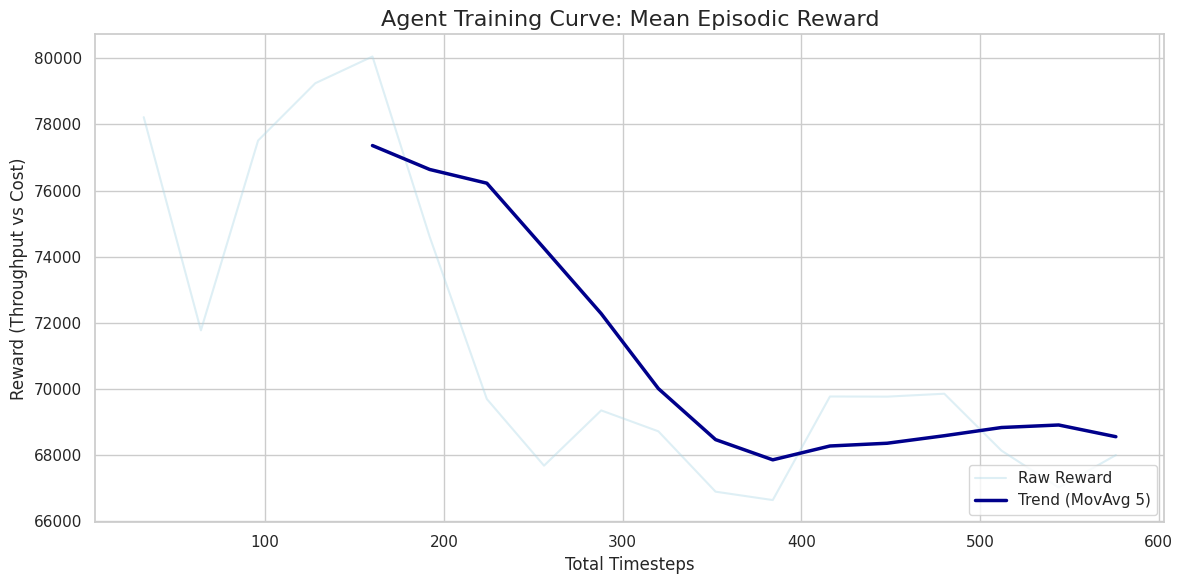

In [ ]:
import os
from tbparse import SummaryReader
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
# CHANGE THIS to match the specific folder name inside your 'logs' directory
# Example: "logs/PPO_LSTM_Run1_0" or "logs/PPO_LSTM_Run1_1"
log_dir = "logs/PPO_LSTM_Run2_0" 
# ---------------------

print(f"Reading logs from: {log_dir}")

# 1. Read the data
try:
    reader = SummaryReader(log_dir)
    df = reader.scalars
    print("Keys found in logs:", df['tag'].unique())
except ValueError as e:
    print("Error reading logs. Make sure the folder path is correct and contains an 'events.out.tfevents' file.")
    df = None

# 2. Filter and Plot
if df is not None and 'rollout/ep_rew_mean' in df['tag'].values:
    # Filter for the reward metric
    rewards_df = df[df['tag'] == 'rollout/ep_rew_mean'].copy()
    
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    
    # A. Plot the Raw Data (Light Blue)
    # This shows the exact reward at every logging step
    sns.lineplot(data=rewards_df, x='step', y='value', color='lightblue', alpha=0.4, label='Raw Reward')
    
    # B. Plot a Smoothed Trend Line (Dark Blue)
    # Reinforcement Learning is noisy; this moving average shows the true trend
    window_size = 3 # Adjust this if the line is too jagged
    rewards_df['smoothed'] = rewards_df['value'].rolling(window=window_size).mean()
    sns.lineplot(data=rewards_df, x='step', y='smoothed', color='darkblue', linewidth=2.5, label=f'Trend (MovAvg {window_size})')
    
    # C. Formatting
    plt.title('Agent Training Curve: Mean Episodic Reward', fontsize=16)
    plt.xlabel('Total Timesteps', fontsize=12)
    plt.ylabel('Reward (Throughput vs Cost)', fontsize=12)
    plt.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

elif df is not None:
    print("\nWARNING: 'rollout/ep_rew_mean' not found yet.")
    print("Possibilities:")
    print("1. The agent hasn't finished its first episode yet (Wait a few minutes).")
    print("2. The log directory path is pointing to an empty or old run.")